# 10. 对抗性防御算法之快速对抗性训练

## 10.0 上节内容回顾与本节主要内容介绍

在之前，我们分别实现了使用FGSM的对抗性训练、使用PGD的对抗性训练以及免费对抗性训练。我们的实验结果表明使用FGSM的对抗性训练效果不佳。然而，在免费对抗性训练中的攻击步骤同样使用了FGSM算法，并且取得了很好的防御性能。在本节中，我们将学习一种新的对抗性训练算法：快速对抗性训练，它几乎与基于FGSM的对抗性训练相同，然而却能够达到更好的防御性能。

本实验的主要内容为采用Python、PyTroch等技术，实现快速对抗性训练算法，并测试其防御能力。

## 10.1 快速对抗性训练介绍

通过之前的实验，我们知道，免费对抗性训练和基于FGSM的对抗性训练十分相似，然而两者的性能却有非常大的差距。
两者在算法过程上的一个重要区别在于，免费对抗性训练的FGSM过程是以上一阶段的攻击结果为起点的。
更一般地说，免费对抗性训练中的FGSM是包含类似于随机初始化的操作。

基于这一发现，快速对抗性训练算法<sup>[1]</sup>在基于FGSM的对抗性训练算法的基础上加入了随机初始化，具体过程如下图<sup>[1]</sup>所示。
快速对抗性训练算法相较于基于FGSM的对抗性训练算法有更好的鲁棒性；相较于PGD5对抗性训练消耗更少的计算资源。

参考文献：

[1] [Wong E, Rice L, Kolter J Z. Fast is better than free: Revisiting adversarial training[J]. arXiv preprint arXiv:2001.03994, 2020.](https://arxiv.org/abs/2001.03994)

<div align=center>
<img src="imgs\fastat.jpg"/>
</div>

## 10.2 导入相关模块

In [2]:
import sys
sys.path.insert(0, r'D:\软件\对抗性防御\对抗性防御-1\03.代码')
import importlib.util
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import os
import logging

from tabulate import tabulate
import test; test_fn = test.test
from loss import LabelSmoothingCrossEntropyLoss, CWLoss
from pgd import LinfPGD
from utils import load_mnist_test
from models import LeNet5, FCNet


logger = logging.getLogger('base')
logger.setLevel(logging.DEBUG)

formatter = logging.Formatter(fmt='%(process)6d %(asctime)s %(message)s', datefmt='%Y%m%d %H:%M:%S')
stream_handler = logging.StreamHandler()
stream_handler.setLevel(logging.DEBUG)
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 10.3 使用快速对抗性训练算法训练模型

使用我们之前实现的AdversarialTraning类可以很容易地实现快速对抗性训练。

In [3]:
from adversarial_training import AdversarialTraining

In [4]:
# 超参数
EPOCH = 5               # 训练总epoch数。FastAT有更快地收敛速度，因此只训练5个epoch
BATCH_SIZE = 256        # 训练batch size大小
LR = 0.001              # 初始学习率
DOWNLOAD_MNIST = False  # 是否下载数据集（已下载设置为False）

EPS = 0.1               # 攻击限制
STEP_SIZE = 0.1         # 攻击步长
STEP = 1                # 攻击步数，在快速对抗性训练中固定为1
RANDOM_START = True     # 攻击是否随机初始化

if not(os.path.exists('./data/')) or not os.listdir('./data/'):
    DOWNLOAD_MNIST = True

In [5]:
# 导入数据，定义数据接口
train_dataset = torchvision.datasets.MNIST(
    root="./data/", train=True, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.MNIST(
    root="./data/", train=False, download=DOWNLOAD_MNIST, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [6]:
# 定义网络结构并统计模型参数
from models import LeNet5

cnn = LeNet5().to(device)
print(cnn)  # 网络结构（这也是PyTorch的一大优点，即可用print很方便的得到网络的直观形式）

# 使用Adam Optimizer
optimizer = torch.optim.Adam(cnn.parameters(), lr=LR)

# 配置损失函数
loss_function = nn.CrossEntropyLoss()

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print('模型参数大小为：', num_params)

LeNet5(
  (conv1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=400, out_features=120, bias=True)
    (1): ReLU()
  )
  (fc2): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): ReLU()
  )
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
模型参数大小为： 61706


In [7]:
cnn_at = AdversarialTraining(cnn, eps=EPS, step=STEP, step_size=STEP_SIZE, random_start=RANDOM_START, is_at=True)

In [8]:
# 以下数据均为训练过程中的对抗性样本所对应数据
train_accs = []
train_losses = []
test_accs = []
test_losses = []

# 保存对应epoch的模型，同时保存训练1个、2个和5个epoch的FastAT模型，验证其鲁棒性是否能快速收敛
save_epochs = [1, 2, 5]

for epoch in range(EPOCH):
    # 训练
    cnn_at.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        n = labels.size(0)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = cnn_at(inputs, labels)

        loss = loss_function(outputs, labels)  # 对抗性训练需要传入标签用于流程中的攻击
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        pred = outputs.max(dim=1).indices        
        train_total += n
        train_correct += (pred == labels).sum().item()
        train_loss += loss.data.item() * n
        
    train_accs.append(train_correct / train_total)
    train_losses.append(train_loss / train_total)
    logger.info(f'training epoch: {epoch}, sobust loss: {train_loss / train_total:.7f}, robust acc: {100 * train_correct / train_total:.2f}%')

    # 测试
    cnn_at.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            n = labels.size(0)

            inputs, labels = inputs.to(device), labels.to(device)
            outputs = cnn_at(inputs, labels)
            loss = loss_function(outputs, labels)
            

            pred = outputs.max(dim=1).indices  
            test_correct += (pred == labels).sum().item()
            test_total += n
            test_loss += loss.data.item() * n

    test_accs.append(test_correct / test_total)
    test_losses.append(test_loss / test_total)

    logger.info(f'    test epoch: {epoch}, robust loss: {test_loss / test_total:.7f}, robust acc: {100 * test_correct / test_total:.2f}%')
    
    # 保存模型
    if (epoch + 1) in save_epochs:
        logger.info(f'正在保存FastAT {epoch + 1}epoch模型...')
        state = {
            'net': cnn.state_dict(),
            'num_epoch': epoch,
            'train_losses': train_losses,
            'train_accs': train_accs,
            'test_losses': test_losses,
            'test_accs': test_accs,
        }

        result_path = f'./save_model/' + str(epoch + 1) + 'epoch'
        if not os.path.isdir(result_path):
            os.makedirs(result_path)
        torch.save(state, result_path + f'/mnist_lenet5_FastAT_{EPS}_{STEP_SIZE}_AT.pth')

 12004 20260207 22:14:46 training epoch: 0, sobust loss: 0.7661032, robust acc: 74.17%
 12004 20260207 22:14:48     test epoch: 0, robust loss: 0.3204064, robust acc: 89.52%
 12004 20260207 22:14:48 正在保存FastAT 1epoch模型...
 12004 20260207 22:14:57 training epoch: 1, sobust loss: 0.2835121, robust acc: 90.87%
 12004 20260207 22:14:59     test epoch: 1, robust loss: 0.2108791, robust acc: 93.26%
 12004 20260207 22:14:59 正在保存FastAT 2epoch模型...
 12004 20260207 22:15:07 training epoch: 2, sobust loss: 0.2115162, robust acc: 93.10%
 12004 20260207 22:15:09     test epoch: 2, robust loss: 0.1793798, robust acc: 94.16%
 12004 20260207 22:15:17 training epoch: 3, sobust loss: 0.1749621, robust acc: 94.24%
 12004 20260207 22:15:19     test epoch: 3, robust loss: 0.1518915, robust acc: 94.83%
 12004 20260207 22:15:27 training epoch: 4, sobust loss: 0.1524237, robust acc: 95.05%
 12004 20260207 22:15:28     test epoch: 4, robust loss: 0.1454202, robust acc: 95.33%
 12004 20260207 22:15:28 正在保存FastA

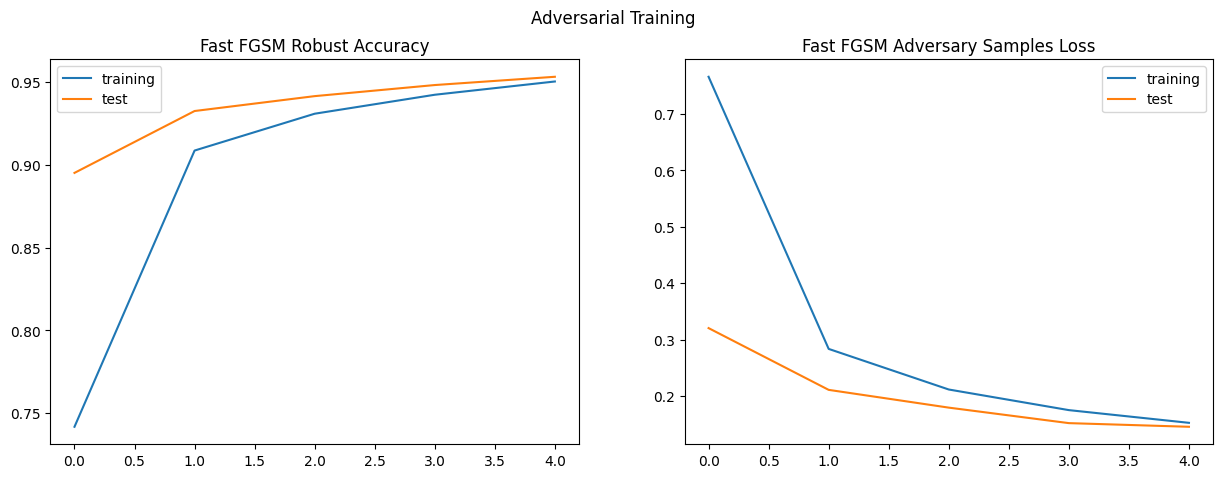

In [9]:
# 训练过程数据展示
plt.figure(figsize=(15, 5))

idx = [_ for _ in range(EPOCH)]
plt.subplot(1, 2, 1)
plt.plot(idx, train_accs, label='training')
plt.plot(idx, test_accs, label='test')
plt.legend()
plt.title('Fast FGSM Robust Accuracy')

plt.subplot(1, 2, 2)
plt.plot(idx, train_losses, label='training')
plt.plot(idx, test_losses, label='test')
plt.legend()
plt.title('Fast FGSM Adversary Samples Loss')

plt.suptitle(f'Adversarial Training')
plt.show()

## 10.4 鲁棒性测试

In [10]:
# 模型加载
cnn_keys = [1, 2, 5]
cnn_dict = {}
for k in cnn_keys:
    state = torch.load(f'./save_model/{k}epoch/mnist_lenet5_FastAT_0.1_0.1_AT.pth')
    cnn_dict[k] = LeNet5()
    cnn_dict[k].load_state_dict(state['net'])
    cnn_dict[k] = cnn_dict[k].to(device)
    cnn_dict[k].eval()

### 10.4.0 白盒攻击测试

In [11]:
# 定义攻击参数
FGSM_kwargs = dict(net=cnn, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=cnn, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

# 加载样本
imgs, lbls = load_mnist_test()

# 执行测试
for k, cnn in cnn_dict.items():
    cln_acc, _ = test_fn(cnn, imgs, lbls, bs=250, mode='clean')                         # 干净样本
    fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
    pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
    cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW
    
    logger.info(f'{k} epoch FastAT Training')
    logger.info(f'Clean: {cln_acc:.2f}, FGSM: {fgsm_acc:.2f}, PGD: {pgd_acc:.2f}, CW: {cw_acc:.2f}')

 12004 20260207 22:15:37 1 epoch FastAT Training
 12004 20260207 22:15:37 Clean: 97.00, FGSM: 92.79, PGD: 92.09, CW: 93.35
 12004 20260207 22:15:51 2 epoch FastAT Training
 12004 20260207 22:15:51 Clean: 98.13, FGSM: 93.89, PGD: 93.11, CW: 94.38
 12004 20260207 22:16:09 5 epoch FastAT Training
 12004 20260207 22:16:09 Clean: 98.62, FGSM: 94.43, PGD: 92.54, CW: 92.57


可以看到，仅1个epoch，FastAT就达到了较稳定的白盒鲁棒性。

### 10.4.1 迁移攻击测试

使用标准模型作为替代模型进行迁移攻击

In [12]:
# 模型加载
std_state = torch.load('./save_model/50epoch/mnist_lenet5.pth')
std_lenet = LeNet5()
std_lenet.load_state_dict(std_state['net'])
std_lenet = std_lenet.to(device)
std_lenet.eval()

# 定义攻击参数
FGSM_kwargs = dict(net=std_lenet, eps=0.1, step=1, step_size=0.1, random_start=False)
PGD_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True)
CW_kwargs = dict(net=std_lenet, eps=0.1, step=20, step_size=0.025, random_start=True, criterion=CWLoss)

# 创建攻击
FGSM = LinfPGD(**FGSM_kwargs)
PGD = LinfPGD(**PGD_kwargs)
CW = LinfPGD(**CW_kwargs)

for k, cnn in cnn_dict.items():
    # 执行测试
    trans_fgsm_acc, _ = test_fn(nn.Sequential(FGSM, cnn), imgs, lbls, bs=250, mode='attack')  # FGSM
    trans_pgd_acc, _ = test_fn(nn.Sequential(PGD, cnn), imgs, lbls, bs=250, mode='attack')    # PGD
    trans_cw_acc, _ = test_fn(nn.Sequential(CW, cnn), imgs, lbls, bs=250, mode='attack')      # CW

    logger.info(f'{k} epoch FastAT Training')
    logger.info(f'Transfer Attack - FGSM: {trans_fgsm_acc:.2f}, PGD: {trans_pgd_acc:.2f}, CW: {trans_cw_acc:.2f}')

 12004 20260207 22:16:23 1 epoch FastAT Training
 12004 20260207 22:16:23 Transfer Attack - FGSM: 95.47, PGD: 95.32, CW: 96.26
 12004 20260207 22:16:40 2 epoch FastAT Training
 12004 20260207 22:16:40 Transfer Attack - FGSM: 96.41, PGD: 96.26, CW: 97.48
 12004 20260207 22:16:53 5 epoch FastAT Training
 12004 20260207 22:16:53 Transfer Attack - FGSM: 97.38, PGD: 97.27, CW: 98.23


结果表明，以标准模型作为替代模型的迁移攻击难以攻破FastAT模型。

### 10.4.2 AutoAttack测试

In [13]:
from autoattack import AutoAttack

In [14]:
for k, cnn in cnn_dict.items():
    adversary = AutoAttack(cnn, eps=0.1, verbose=False)

    x_adv = adversary.run_standard_evaluation(imgs, lbls)
    aa_acc, _ = test_fn(cnn, x_adv, lbls)
    logger.info(f'{k} epoch FastAT Training AutoAttack Acc: {aa_acc:.2f}')

 12004 20260207 22:48:14 1 epoch FastAT Training AutoAttack Acc: 84.60
 12004 20260207 23:22:00 2 epoch FastAT Training AutoAttack Acc: 89.45
 12004 20260207 23:56:50 5 epoch FastAT Training AutoAttack Acc: 92.07


回顾之前的防御模型性能（实验存在随机因素，实验结果会有微小的波动）：
- 仅使用干净样本进行训练的标准模型 - 17.40
- 使用label smoothing进行训练的模型 - 8.47
- 使用FGSM进行50epoch对抗性训练的模型 - 36.48
- 使用PGD5进行50epoch对抗性训练的模型 - 95.02

在本节中，仅训练1个epoch的FastAT模型，其防御性能已经接近使用PGD5进行50epoch对抗性训练的模型，要远远超过使用FGSM进行对抗性训练的模型，而FastAT与FGSM-AT的差别仅在训练中的攻击是否以随机扰动初始化。